## Simulation Setup
Configure CMB power spectra, noise model, and generate the simulated sky maps used throughout the analysis.

In [134]:
import Pkg
Pkg.activate("/Users/megdearden-hellawell/Documents/Physics Part III/CMB_Project")
Pkg.instantiate()

  Activating project at `~/Documents/Physics Part III/CMB_Project`


In [135]:
using Revise
includet("utils.jl")   # note: includet
using .Utils

In [165]:
using CMBLensing
using PythonPlot


Cℓ  = camb(r=0.05, ℓmax=21000)         
Cℓn = noiseCℓs(μKarcminT=1.0, ℓknee=0, ℓmax=12000)



θpix  = 0.7438046267475303  # pixel size in arcmin
Nside = 512     # number of pixels per side in the map
pol   = :I       # type of data to use (can be :T, :P, or :TP)
T     = Float64  # data type;
bandpass_mask = LowPass(12000);

(;f, f̃, ϕ, ds) = load_sim(
    seed = 3,
    Cℓ = Cℓ,
    Cℓn = Cℓn,
    θpix = θpix,
    T = T,
    Nside = Nside,
    beamFWHM = 1.0,
    pol = pol,
    bandpass_mask = bandpass_mask, 
    Nϕ_fac=6,
    pixel_mask_kwargs = (edge_padding_deg=0, apodization_deg=0, num_ptsrcs=0),
)



(f = ComplexF64[0.0 + 0.0im, 2.7411964827581863e6 + 5.003465608248525e6im, 1.7547807421365988e6 + 876278.0527242104im, -95708.00161310287 - 658934.7395465916im, -1.5271750326498207e6 - 1.2887820663139247e6im, -2.0969763136845664e6 + 292729.53829214384im, -232178.74682883205 + 504967.2333905162im, 932729.8108262222 - 292551.6431064404im, 246771.4057287689 - 271199.48687010905im, -101978.96494105224 + 165132.361689678im  …  -2.355084956458778 - 10.755192630467317im, -3.8660872624940277 + 9.658641166990886im, -0.3416366908085002 - 2.8081575429363763im, 0.854311900087241 + 1.746193252217182im, 4.955090544011099 - 0.8990022975069879im, 0.9791091730927487 + 6.647756041701661im, -15.02981479045677 + 4.473163662143111im, 11.306764266060254 - 9.079476702290103im, -0.43000067150339377 - 6.049125050499738im, -6.986996941795545 - 3.7141478983135805im], f̃ = [-133.54025871781874, -134.54947364840874, -134.07820741086832, -132.88745692712212, -130.3944656497282, -127.36917328990494, -123.93370129601

## Quadratic Estimator
Compute the quadratic estimate of the lensing potential from the observed data.

In [166]:
qe = quadratic_estimate(ds; weights=:lensed, wiener_filtered=true)
ϕqe = qe.ϕqe


131584-element 512×512-pixel 0.7438046267475303′-resolution LambertFourier{Array{ComplexF64, 2}}:
                    -0.0 - 0.0im
      0.5653442550142463 - 0.005904896365155694im
     0.11175245920526439 - 0.0008681180230290273im
   -0.016549014820064132 - 0.013268017179386736im
   -0.028211471596588832 - 5.0660789980616905e-5im
    0.006826907371315548 + 0.009957928298114494im
   0.0015431843842918912 + 0.0038439261121210005im
  -0.0015670563756337052 - 0.0013151832528797668im
   0.0016092934234437858 - 0.003872777905771712im
   -0.004080143698649701 + 0.003482097747178676im
                         ⋮
 -1.8396858016921945e-11 + 5.501819594960495e-10im
  -5.639683842112105e-10 + 2.343897553633697e-10im
  -9.924334278219973e-11 - 5.387331498165338e-10im
  4.7881165863714105e-11 - 1.815578952532443e-10im
  2.3693561919159415e-10 + 3.121333554427856e-11im
  1.9417769551956767e-10 + 6.746253200937665e-10im
  -6.621246023458932e-10 - 5.427159024984427e-10im
  1.4571910842118327e-10 + 1.65

GI estimate

In [138]:
ϕgi = gi_estimate(ds; Lgrad=2000, Lhp=4000, Lmax=12000)


ρ_gi_check = Float64.(get_Cℓ(ϕ, ϕgi; Δℓ=200).Cℓ) ./ 
             sqrt.(Float64.(get_Cℓ(ϕ; Δℓ=200).Cℓ) .* Float64.(get_Cℓ(ϕgi; Δℓ=200).Cℓ))
println("ρ_GI at L~4000: ", ρ_gi_check[end÷2])  # rough check


ρ_GI at L~4000: 0.18479300363169973


In [ ]:
# GI estimate (valid for L > 3000)
ϕgi = gi_estimate(ds; Lgrad=2000, Lhp=4000, Lmax=18000)

# Hybrid start: QE at low-L, GI at high-L
ϕ_start = Map(LowPass(3000) * ϕqe) + Map(HighPass(3000) * ϕgi)

# MAP_joint from GI hybrid start
result = MAP_joint(ds, FieldTuple(ϕ=ϕ_start);
    nsteps=20, nburnin_update_hessian=Inf,
    conjgrad_kwargs=(tol=1e-4, nsteps=200), progress=true)
ϕJ = result.ϕ


InterruptException: InterruptException:

## Joint MAP Reconstruction
Perform joint maximum a posteriori estimation of the CMB and lensing potential.

In [ ]:
using CMBLensing: Map, Loess

loess = Loess.loess   

qe = quadratic_estimate(ds; weights=:lensed, wiener_filtered=true)
Ωstart = FieldTuple(ϕ = qe.ϕqe)

result = MAP_joint(
    ds, Ωstart;
    nsteps = 40,
    nburnin_update_hessian = Inf,
    conjgrad_kwargs = (tol=1e-4, nsteps=100),
    #αtol = 1e-5,
    progress = true,
)

fJ = result.f
ϕJ = result.ϕ
hist = result.history


MAP_joint:   3%|█▍                                      |  ETA: 0:03:43





MAP_joint:   7%|██▋                                     |  ETA: 0:03:23





MAP_joint:  10%|████                                    |  ETA: 0:03:07





MAP_joint:  13%|█████▍                                  |  ETA: 0:03:04





MAP_joint:  17%|██████▋                                 |  ETA: 0:03:00





MAP_joint:  20%|████████                                |  ETA: 0:02:49





MAP_joint:  23%|█████████▍                              |  ETA: 0:02:36





MAP_joint:  27%|██████████▋                             |  ETA: 0:02:25





MAP_joint:  30%|████████████                            |  ETA: 0:02:15





MAP_joint:  33%|█████████████▍                          |  ETA: 0:02:05





MAP_joint:  37%|██████████████▋                         |  ETA: 0:01:57





MAP_joint:  40%|████████████████                        |  ETA: 0:01:51





MAP_joint:  43%|█████████████████▍                      |  ETA: 0:01:44






30-element Vector{Any}:
 (logpdf = 6.1794062291024625e6,)
 (logpdf = 6.179946200988551e6,)
 (logpdf = 6.180324439464004e6,)
 (logpdf = 6.18054591249424e6,)
 (logpdf = 6.180666877590042e6,)
 (logpdf = 6.180734997651802e6,)
 (logpdf = 6.180776861662851e6,)
 (logpdf = 6.180805051410809e6,)
 (logpdf = 6.180825507924628e6,)
 (logpdf = 6.180841170686838e6,)
 ⋮
 (logpdf = 6.1809165538341915e6,)
 (logpdf = 6.180919495894902e6,)
 (logpdf = 6.180922226640078e6,)
 (logpdf = 6.180924770198079e6,)
 (logpdf = 6.180927146961753e6,)
 (logpdf = 6.180929374304757e6,)
 (logpdf = 6.18093146713649e6,)
 (logpdf = 6.180933438336759e6,)
 (logpdf = 6.180935299099895e6,)

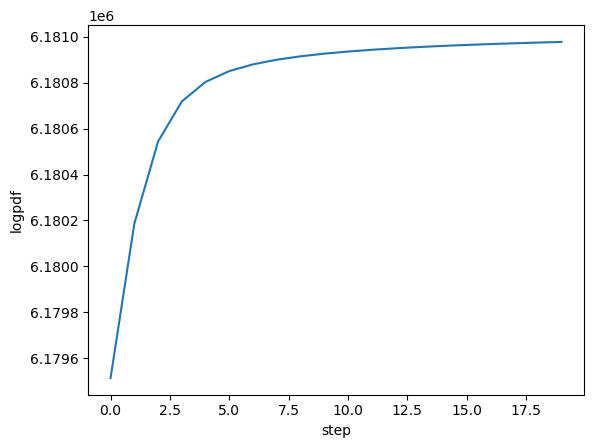

In [162]:
plt = PythonPlot
plt.figure()
plt.plot(getindex.(hist, :logpdf))
plt.xlabel("step")
plt.ylabel("logpdf")
gcf()


## Marginal MAP Reconstruction
Perform marginal MAP estimation of the lensing potential, integrating over the CMB field.

In [141]:
CMBLensing.@distributed ds
@eval CMBLensing begin
    # Only define fallback if the real functions do NOT exist
    if !@isdefined(set_distributed_dataset)
        @info "CMBLensing: set_distributed_dataset not found — using fallback."

        const _DIST_DS = Ref{Any}(nothing)
        set_distributed_dataset(x) = (_DIST_DS[] = x)
        get_distributed_dataset() = _DIST_DS[]

    else
        @info "CMBLensing: using real distributed dataset system."
    end
end



   CG (data): 5 iterations
┌ Info: CMBLensing: using real distributed dataset system.
└ @ CMBLensing /Users/megdearden-hellawell/Documents/Physics Part III/CMB_Project/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X16sZmlsZQ==.jl:12


In [ ]:

# --- MAP_marg call ---
ϕ_marg, hist_marg = MAP_marg(
    ds, ϕstart = ϕ_start;
    nsteps = 30,
    nsteps_with_meanfield_update = 10,
    Nsims = 100,  
    conjgrad_kwargs = (tol=1e-4, nsteps=200),
    α = 0.02,       # ← default is 0.2; MAP_joint converges at α≈0.018
    progress = true,
    pmap = map
)




MAP_marg:   0%|▏                                        |  ETA: 3:21:08


MAP_marg:   0%|▏                                        |  ETA: 2:14:46


MAP_marg:   1%|▎                                        |  ETA: 1:43:46


MAP_marg:   1%|▍                                        |  ETA: 1:34:19


MAP_marg:   1%|▌                                        |  ETA: 1:28:29


MAP_marg:   1%|▌                                        |  ETA: 1:27:30


MAP_marg:   2%|▋                                        |  ETA: 1:27:37


MAP_marg:   2%|▊                                        |  ETA: 1:25:23


MAP_marg:   2%|▊                                        |  ETA: 1:23:01


MAP_marg:   2%|▉                                        |  ETA: 1:21:12


MAP_marg:   2%|█                                        |  ETA: 1:19:03


MAP_marg:   3%|█                                        |  ETA: 1:17:58


MAP_marg:   3%|█▏                                       |  ETA: 1:16:57


MAP_marg:   3%|█▎                     

## Power Spectrum Comparison
Compare the angular power spectra of the true, QE, and MAP-reconstructed lensing potentials.

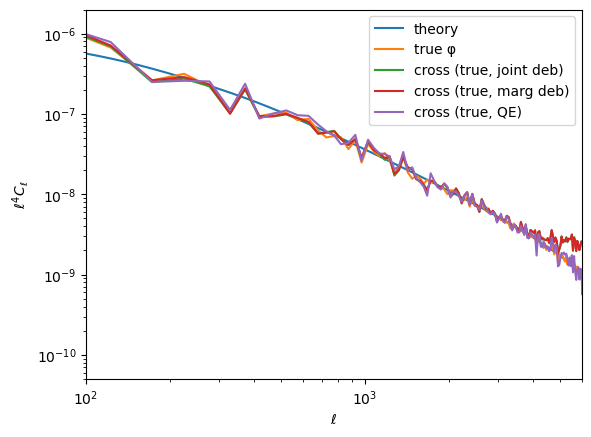

In [121]:
using CMBLensing: get_ρℓ, get_ℓ⁴Cℓ
# ------------------------------------------------------------------
# 5) Compare spectra
# ------------------------------------------------------------------


figure()
loglog(ℓ⁴ * Cℓ.total.ϕϕ,                label="theory")
loglog(get_ℓ⁴Cℓ(ϕ),                     label="true φ")
loglog(get_ℓ⁴Cℓ(ϕ, ϕ_joint_deb),        label="cross (true, joint deb)")
loglog(get_ℓ⁴Cℓ(ϕ, ϕ_marg_deb),         label="cross (true, marg deb)")
loglog(get_ℓ⁴Cℓ(ϕ, ϕqe_deb),               label="cross (true, QE)")
xlim(100, 6000); ylim(5e-11, 2e-6); legend()
xlabel(raw"$\ell$")
ylabel(raw"$\ell^4 C_\ell$")
gcf()







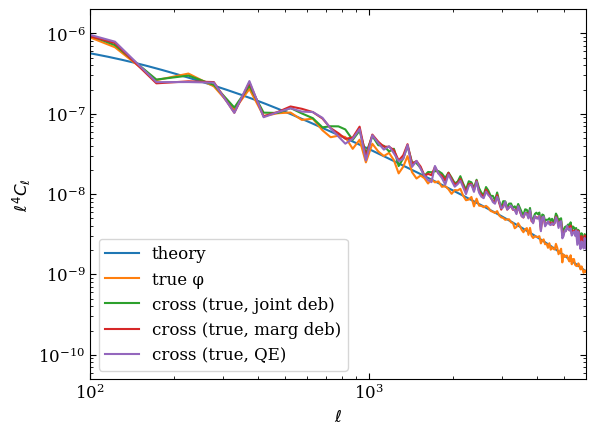

In [146]:
using CMBLensing: get_ρℓ, get_ℓ⁴Cℓ
# ------------------------------------------------------------------
# 5) Compare spectra
# ------------------------------------------------------------------


figure()
loglog(ℓ⁴ * Cℓ.total.ϕϕ,                label="theory")
loglog(get_ℓ⁴Cℓ(ϕ),                     label="true φ")
loglog(get_ℓ⁴Cℓ(ϕ, ϕ_joint_deb),        label="cross (true, joint deb)")
loglog(get_ℓ⁴Cℓ(ϕ, ϕ_marg_deb),         label="cross (true, marg deb)")
loglog(get_ℓ⁴Cℓ(ϕ, ϕqe_deb),               label="cross (true, QE)")
xlim(100, 6000); ylim(5e-11, 2e-6); legend()
xlabel(raw"$\ell$")
ylabel(raw"$\ell^4 C_\ell$")
gcf()


## Lensing Map Visualisation
Visual comparison of the true and reconstructed lensing potential maps.

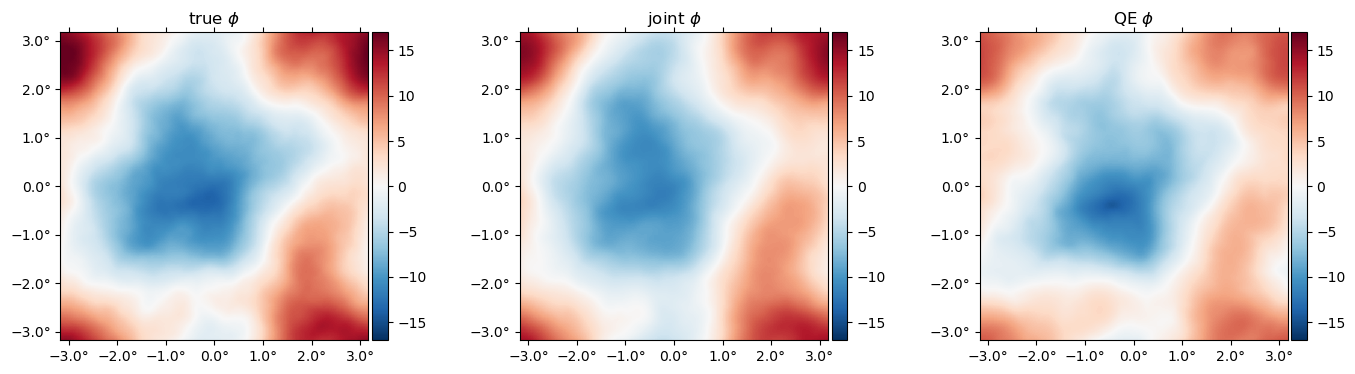

In [ ]:
# ------------------------------------------------------------------
# 5) Lensing map visualisation
# ------------------------------------------------------------------
PythonPlot.plot(
    1e6 .* [ϕ  ϕJ ϕqe],
    title = ["true" "joint" "QE"] .* raw" $\phi$",
    vlim = 17
)

## Correlation Coefficient vs Multipole
Compute and plot the cross-correlation coefficient $\rho_\ell$ between the true and reconstructed lensing potentials.

In [14]:

qe_false = quadratic_estimate(ds; weights=:unlensed, wiener_filtered=false)
ϕqe_false = qe_false.ϕqe

131584-element 512×512-pixel 0.7438046267475303′-resolution LambertFourier{Array{ComplexF64, 2}}:
                   -0.0 - 0.0im
      7.120995884797383 - 1.4358845757189451im
     1.6805627060261374 - 0.5097624916296593im
     0.8104984071038439 - 0.3224653899272856im
   -0.18663323747196628 - 0.22586512442108456im
   -0.07755639828108939 - 0.12043103477438705im
   -0.07354228839666678 - 0.21121033643023976im
  -0.011572215269043852 - 0.09262236844647924im
    0.13602443261113722 - 0.06613477582924145im
    -0.0304324799233804 + 0.0909477983609073im
                        ⋮
   8.371662160704187e-8 + 1.6848198718071826e-7im
  -3.646288037708134e-8 + 8.572148779485831e-8im
  1.2863726734267219e-7 - 1.390295344119256e-7im
  1.3801717894875562e-7 - 5.326250810849817e-9im
 -2.1702226847366227e-7 - 1.6462922769917553e-7im
   -7.48581301268552e-8 - 2.6973806026649794e-7im
  2.0611739748330477e-7 + 2.039337773268885e-8im
  -2.006067911964215e-8 - 5.650278308284527e-8im
  -8.175605448913586e

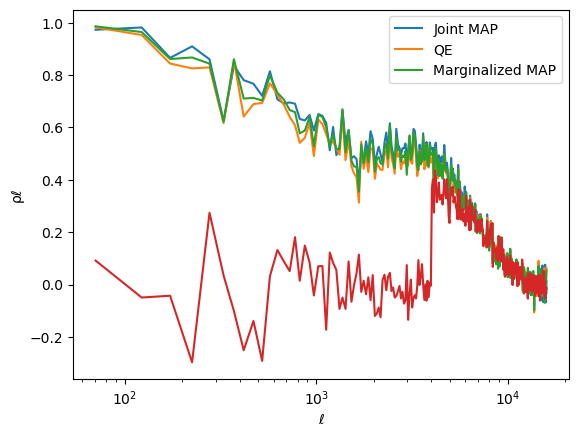

In [142]:
# ------------------------------------------------------------------
# 6) Correlation coefficient vs ell (ρℓ)
# ------------------------------------------------------------------
figure()
semilogx(get_ρℓ(ϕ, ϕJ))
semilogx(get_ρℓ(ϕqe, ϕ))
semilogx(get_ρℓ(ϕ_marg, ϕ))
semilogx(get_ρℓ(ϕgi, ϕ))

xlabel("ℓ")
ylabel("ρℓ")
legend(["Joint MAP", "QE", "Marginalized MAP"])
gcf()

## Custom FFT-Based Spectra
Compute cross-correlation coefficients using FFT-based power spectrum estimation with adjustable binning.

In [80]:
# QE reconstruction

# True, MAP and QE spectra
C_true     = get_Cℓ_fft(ϕ)              # C_ℓ^{φφ}
C_map      = get_Cℓ_fft(ϕJ)             # C_ℓ^{φ̂_MAP φ̂_MAP}
C_qe       = get_Cℓ_fft(ϕqe)           # C_ℓ^{φ̂_QE  φ̂_QE}
C_crossMAP = get_Cℓ_fft(ϕ, ϕJ)          # C_ℓ^{φ φ̂_MAP}
C_crossQE  = get_Cℓ_fft(ϕ, ϕqe)        # C_ℓ^{φ φ̂_QE}

ℓ = C_crossMAP.ℓ              # all have the same ℓ grid

ρ_map = C_crossMAP.Cℓ ./ sqrt.(C_true.Cℓ .* C_map.Cℓ)
ρ_qe  = C_crossQE.Cℓ  ./ sqrt.(C_true.Cℓ .* C_qe.Cℓ)


300-element Vector{Float64}:
  0.9970723703710952
  0.8048005454832411
  0.7439333999042803
  0.8310004688955744
  0.7202591927451597
  0.7931865924527307
  0.5605128397891387
  0.6665119288105424
  0.7629065429180187
  0.718299161016947
  ⋮
  0.03548970333235301
  0.04028641457748594
  0.1882282851125157
  0.04120701627025854
  0.09758483408076832
  0.1341645486057613
 -0.0019190144878497748
 -0.17621693102154132
  0.3185492942935092

## Binned Correlation Coefficients
Recompute the QE and bin the cross-correlation coefficients $\rho_\ell$ for smoother comparison across estimators.

In [ ]:
using Statistics: mean
function bin_spectrum(ells, vals; ΔL=300)
    Lmin, Lmax = minimum(ells), maximum(ells)
    edges = collect(Lmin:ΔL:Lmax)
    centers = @. 0.5*(edges[1:end-1] + edges[2:end])

    binned = similar(centers)
    for i in eachindex(centers)
        mask = (ells .>= edges[i]) .& (ells .< edges[i+1])
        binned[i] = any(mask) ? mean(vals[mask]) : NaN
    end

    return centers, binned
end
# --- Compute correlations ---
ρ_map  = get_ρℓ(ϕ,      ϕJ)
ρ_qe   = get_ρℓ(ϕqe, ϕ)
ρ_marg = get_ρℓ(ϕ_marg, ϕ) 
ρ_gi   = get_ρℓ(ϕgi, ϕ)

# --- Bin for smoothing ---
ΔL = 300       
Lmap,  ρmap_b  = bin_spectrum(ρ_map.ℓ,  ρ_map.Cℓ;  ΔL=ΔL)
Lqe,   ρqe_b   = bin_spectrum(ρ_qe.ℓ,   ρ_qe.Cℓ;   ΔL=ΔL)
Lmarg, ρmarg_b = bin_spectrum(ρ_marg.ℓ, ρ_marg.Cℓ; ΔL=ΔL)  
Lgi,   ρgi_b   = bin_spectrum(ρ_gi.ℓ,   ρ_gi.Cℓ;   ΔL=ΔL)

# --- Plot (linear x-axis) ---
plt = PythonPlot
plt.figure(figsize=(7,4))

plt.plot(Lmap,  ρmap_b,  label="Joint MAP")
plt.plot(Lqe,   ρqe_b,   label="QE")
plt.plot(Lmarg, ρmarg_b, label="MAP_marg")   
#plt.plot(Lgi,   ρgi_b,   label="GI")

plt.axhline(1, color="k", linestyle="--", linewidth=0.8)

plt.xlim(0, 6000)      
plt.ylim(0, 1)

plt.xlabel("ℓ")
plt.ylabel("ρₗ")
plt.legend()
plt.title("Correlation Coefficient vs l (Bandpass 12000, 1.0 μK-arcmin)")
plt.tight_layout()
plt.show()
gcf()

## Empirical Wiener Filter Estimation
Estimate the transfer function $W_L$ from Monte Carlo simulations to correct for multiplicative bias in the MAP reconstructions.

In [202]:
using JLD2: @load, @save

@load "results/WL_checkpoint_8000.jld2" ℓ_template W_joint_running W_marg_running W_qe_running
ℓ = ℓ_template
WL_emp_joint = W_joint_running
WL_emp_marg  = W_marg_running
WL_emp_qe    = W_qe_running

532-element Vector{Float64}:
  0.7793500078925939
  0.7932180771200789
  0.8333608288424313
  0.8036311829304686
  0.7517158967016929
  0.752936535324964
  0.7284611111283997
  0.7092636136410729
  0.6936037061973896
  0.6766294714705643
  ⋮
  3.0646879494574442e-9
  1.3812651952636514e-8
 -9.79632693976453e-8
 -5.860934655732231e-8
  6.6517095796800335e-9
 -1.0638354419424582e-9
 -1.635704257184781e-8
  3.455708979178541e-9
 -2.3181611579632649e-10

## Debiasing the Lensing Potential
Apply the empirical Wiener filter $W_L$ to correct for the multiplicative bias in the MAP reconstructions.

In [31]:
using Revise
includet("utils.jl")
using .Utils


In [135]:
using CMBLensing: BaseField, Fourier
WL_joint_Cℓs = Cℓs(ℓ_template, W_joint_running)
WL_marg_Cℓs  = Cℓs(ℓ_template, W_marg_running)
WL_qe_Cℓs    = Cℓs(ℓ_template, W_qe_running)



Cℓs{Vector{Float64}, Vector{Float64}}([56.71852322897651, 80.21210478819201, 113.43704645795302, 126.82647352339232, 172.6796575386422, 204.5015437706701, 231.5756986720525, 249.4647884469604, 285.8655499743619, 310.74483896266247  …  15704.969292448668, 15733.632960628947, 15765.162638656157, 15796.420235184363, 15825.21835929624, 15853.816642154286, 15884.378996073348, 15915.38682436355, 15944.426223994742, 15974.42111144368], [0.7940270114311561, 0.8023201052380083, 0.8105922098242401, 0.8086554489718294, 0.7557061374130866, 0.7521336156826992, 0.7263639609762219, 0.7051348728996856, 0.6879708483035321, 0.6774388327780739  …  -3.110280953095888e-20, -2.0105740873858162e-20, 1.8748578026995954e-20, 2.6437536639757676e-22, 1.593255382981065e-20, -3.910398917569649e-21, 1.711125986231774e-20, 3.219594132882013e-20, -3.156518700462759e-23, 3.7019481520830447e-20], true, CMBLensing.var"#105#106"{Float64, Vector{Float64}, Vector{Float64}, Vector{Float64}}(NaN, [56.71852322897651, 80.21210

In [136]:

ϕ_joint_deb = debias_phi_with_WL(ϕJ, WL_joint_Cℓs; minW=1e-8)
ϕ_marg_deb  = debias_phi_with_WL(ϕ_marg,  WL_marg_Cℓs;  minW=1e-8)
ϕqe_deb = debias_phi_with_WL(ϕqe, WL_qe_Cℓs; minW=1e-8)

131584-element 512×512-pixel 0.7438046267475303′-resolution LambertFourier{Array{ComplexF64, 2}}:
                    -0.0 - 0.0im
      0.7287238001350393 - 0.044565273245701906im
     0.15007021605922588 + 0.03152866793679677im
    -0.02195307686123711 - 0.013827966114069879im
    -0.04490884770793118 + 0.006788653595030977im
    0.011570168146668424 + 0.015054992876678504im
  -0.0005239791152594061 + 0.0071857686256325im
  -0.0008846058214746462 - 0.001975747507962839im
    0.003876436265068541 - 0.008630547145995425im
   -0.009038410127188637 + 0.006487547265457474im
                         ⋮
    2.18812085938589e-25 + 1.1762267321960314e-24im
  -3.317280603951042e-25 + 1.4863711109116562e-25im
    3.63516491616378e-25 - 5.107229587628069e-25im
  -8.450484875290312e-25 + 1.2294623849924517e-24im
   -2.63431681264773e-25 + 6.50938728254146e-25im
   2.397121368751033e-25 - 1.503456317778538e-25im
  -8.109995599413944e-25 - 3.4888279892836003e-25im
 -1.2657131295288233e-24 - 4.221768

## Gradient-Dependent Reconstruction Error
Investigate the spatial correlation between CMB temperature gradients and lensing reconstruction errors.

In [165]:
function plot_phi_error_vs_gradT_old(f, ϕ, ϕqe, ϕ_J, ϕ_marg; nbins=20, min_count=10)
    _, _, grad_mag = grad_fft(f)

    ΔϕQE   = Float64.((Map(ϕ) - Map(ϕqe)).arr)
    ΔϕJ    = Float64.((Map(ϕ) - Map(ϕ_J)).arr)
    Δϕmarg = Float64.((Map(ϕ) - Map(ϕ_marg)).arr)

    e_QE   = abs.(ΔϕQE) .^ 2
    e_J    = abs.(ΔϕJ) .^ 2
    e_marg = abs.(Δϕmarg) .^ 2
    cen, m_QE,   s_QE,   n_QE   = bin_stat_err(Float64.(grad_mag), e_QE;   nbins=nbins)
    _,   m_J,    s_J,    n_J    = bin_stat_err(Float64.(grad_mag), e_J;    nbins=nbins)
    _,   m_marg, s_marg, n_marg = bin_stat_err(Float64.(grad_mag), e_marg; nbins=nbins)

    ok_QE   = n_QE   .>= min_count
    ok_J    = n_J    .>= min_count
    ok_marg = n_marg .>= min_count

    plt.rc("font",   size=12, family="serif")
    plt.rc("axes",   linewidth=0.8)
    plt.rc("xtick",  direction="in", top=true)
    plt.rc("ytick",  direction="in", right=true)
    plt.rc("xtick.major", width=0.8, size=4)
    plt.rc("ytick.major", width=0.8, size=4)

    colours = ["#4477AA", "#EE6677", "#228833"]

    fig, ax = plt.subplots(figsize=(5.5, 4))

    for (ok, m, s, col, lab, mk) in [
        (ok_QE,   m_QE,   s_QE,   colours[1], "QE",        "o"),
        (ok_J,    m_J,    s_J,    colours[2], "Joint MAP",  "s"),
        (ok_marg, m_marg, s_marg, colours[3], "MAP marg",   "^"),
    ]
        c, μ, σ = cen[ok], m[ok], s[ok]
        ax.plot(c, μ, marker=mk, color=col, label=lab,
                markersize=4, linewidth=1.2, markeredgewidth=0.6, markeredgecolor="white")
        ax.fill_between(c, μ .- σ, μ .+ σ, alpha=0.2, color=col)
    end

    ax.set_xlabel(L"|\nabla T|\;\mathrm{(per\;pixel)}", fontsize=13)
    ax.set_ylabel(L"\langle|\Delta\phi|^2\rangle", fontsize=13)
    ax.legend(frameon=false, fontsize=11)
    ax.tick_params(labelsize=11)
    ax.spines["top"].set_visible(false)
    ax.spines["right"].set_visible(false)

    fig.tight_layout()
end


plot_phi_error_vs_gradT_old (generic function with 1 method)

In [ ]:
plot_phi_error_vs_gradT_old(f, ϕ, ϕqe_deb, ϕ_joint_deb, ϕ_marg_deb; nbins=20, min_count=10)
gcf()

In [9]:
using PythonPlot
plt = PythonPlot

PythonPlot

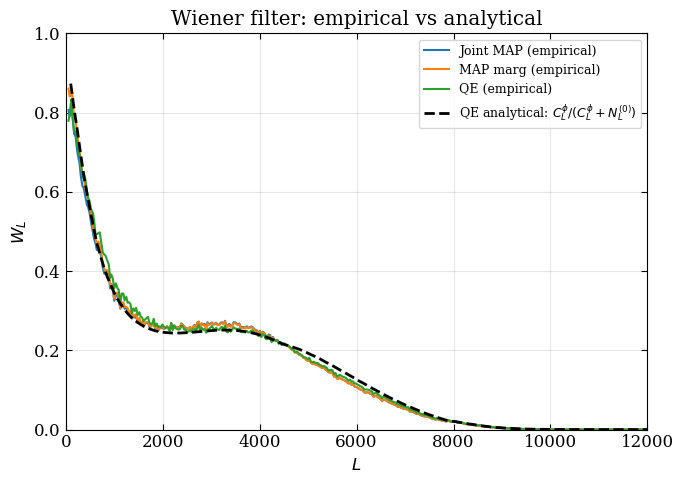

In [238]:
# ── Analytical W_L = C_L^{φφ} / (C_L^{φφ} + N_L^{(0)}) ──────────────────────
# ds.Cϕ is a ParamDependentOp — call () to get the underlying DiagOp
# qe.Nϕ is already a DiagOp (= A_L, the QE normalisation)
qe = quadratic_estimate(ds; weights=:unlensed, wiener_filtered=true)  # to get qe.Nϕ
Cϕ_op  = ds.Cϕ()          # DiagOp: C_L^{φφ} on the 2D Fourier grid
Nϕ_op  = qe.Nϕ            # DiagOp: N_L^{(0)} on the 2D Fourier grid

cphi_2d = real.(Cϕ_op.diag.arr)   # (Ny/2+1) × Nx half-plane array
nphi_2d = real.(Nϕ_op.diag.arr)

W2d = cphi_2d ./ (cphi_2d .+ nphi_2d )

# ℓ magnitude on the same half-plane rfft grid
proj   = ds.d.proj
ℓmag2d = proj.ℓmag        # matches size of .arr for FlatFourier fields

# Bin W2d into 1D using bin_stat (from spectra.jl)
ℓc_ana, WL_ana_binned = bin_stat(vec(Float64.(ℓmag2d)), vec(W2d); nbins=300)

# ── Plot against empirical W_L ─────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
plt.plot(ℓ_template, WL_emp_joint, label="Joint MAP (empirical)")
plt.plot(ℓ_template, WL_emp_marg,  label="MAP marg (empirical)")
plt.plot(ℓ_template, WL_emp_qe,    label="QE (empirical)")
plt.plot(ℓc_ana, WL_ana_binned,
         color="black", linestyle="--", linewidth=2,
         label=L"QE analytical: $C_L^\phi / (C_L^\phi + N_L^{(0)})$")
plt.xlabel(L"L");  plt.ylabel(L"W_L")
plt.xlim(0, 12000); plt.ylim(0, 1.0)
plt.legend(fontsize=9); plt.grid(true, alpha=0.3)
plt.title("Wiener filter: empirical vs analytical")
plt.tight_layout()
gcf()

In [117]:
using JLD2
@load "results/WL_checkpoint_new.jld2" ℓ_template W_qe_running
println("ℓ range: ", extrema(ℓ_template))
# find where W_qe drops below threshold
idx = findlast(W_qe_running .> 1e-3)
println("W_qe drops below 1e-3 at ℓ ≈ ", ℓ_template[idx])


ℓ range: (56.71852322897651, 15974.42111144368)
W_qe drops below 1e-3 at ℓ ≈ 8055.779631879959


In [61]:
function plot_WL_comparison1(
    L_template, WL_joint, WL_marg, WL_qe;
    Lcut=2000
)

    L  = collect(L_template)
    WJ = collect(WL_joint)
    WM = collect(WL_marg)
    WQ = collect(WL_qe)

    mask = (L .> 0) .& (L .<= Lcut)

    plt.figure(figsize=(7, 5))

    for (W, lab, col) in [
        (WJ, "MAP joint (empirical)", "#4477AA"),
        (WM, "MAP marg (empirical)",  "#EE6677"),
        (WQ, "QE (empirical)",        "#228833"),
    ]
        plt.plot(L[mask], W[mask], label=lab, color=col)
    end

    plt.xlabel("L")
    plt.ylabel("W_L")
    plt.xlim(0, Lcut)
    plt.legend()
    plt.grid(true, alpha=0.3)
    plt.tight_layout()
end

plot_WL_comparison1 (generic function with 1 method)

In [62]:
WL_emp_joint = W_joint_running
WL_emp_marg  = W_marg_running
WL_emp_qe    = W_qe_running

532-element Vector{Float64}:
  0.8511408517891768
  0.8727081399102061
  0.6489141342251374
  0.962213687906406
  0.4608477366136676
  0.3303589716020005
  0.25850934294851036
  0.15419505291586666
  0.06382922548075623
  0.07024404351173894
  ⋮
 -2.14320880974076e-31
 -1.1021144833993278e-30
 -9.262264877665497e-31
  9.572033118179401e-32
  5.838272000101724e-32
  2.871458448567834e-31
  2.693202396347637e-31
 -1.4548846563153499e-30
  7.000422437356553e-31

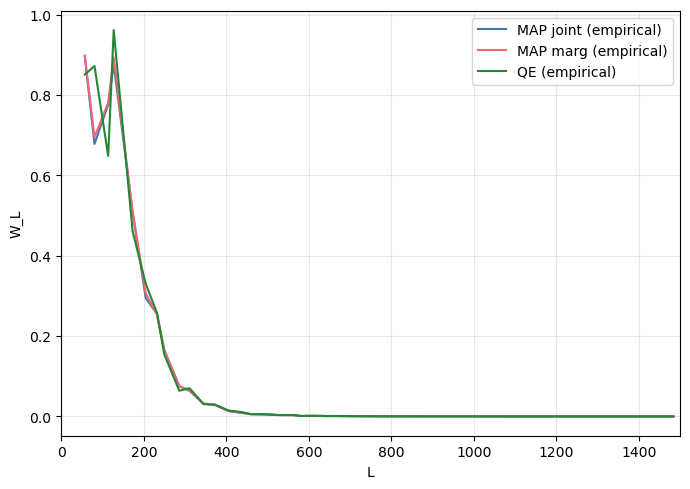

In [63]:
plot_WL_comparison1(
    ℓ_template,
    W_joint_running,
    W_marg_running,
    W_qe_running;
    Lcut = 1500
)
gcf()

## Analytical Normalisation
Compute the iterative QE normalisation $R_L$ following Legrand & Carron (2022) and derive the analytical Wiener filter for comparison with the empirical estimate.

In [ ]:

# ------------------------------------------------------------
# 1. Compute analytic WL (iterative QE, temperature estimator)
# ------------------------------------------------------------

out = compute_WL_iterative_QE_TT(ds; niter=30)

WL_analytic = out.WL
N0_analytic = out.N0
RL_analytic = out.RL
Cϕ_resid    = out.Cϕ_res


In [ ]:
using PythonPlot
using Statistics

# ------------------------------------------------------------
# 2. Prepare ℓ values for each Fourier mode
# ------------------------------------------------------------
proj = ds.d.proj
ℓmag_flat = vec(proj.ℓmag)
WL_flat   = vec(WL_ana)

# ------------------------------------------------------------
# 3. Bin using the SAME bins as empirical W_L
# ------------------------------------------------------------
ℓ_emp = collect(ℓ)               # empirical bin centres
nbins = length(ℓ_emp)

edges = similar(ℓ_emp, nbins + 1)
edges[2:nbins] .= 0.5 .* (ℓ_emp[1:end-1] .+ ℓ_emp[2:end])
edges[1]  = 0.0
edges[end] = maximum(ℓmag_flat) * 1.001

WL_ana_binned = fill(NaN, nbins)
ℓc_ana        = similar(WL_ana_binned)

for i in 1:nbins
    mask = (edges[i] .<= ℓmag_flat .< edges[i+1])
    if any(mask)
        WL_ana_binned[i] = mean(WL_flat[mask])
        ℓc_ana[i]        = mean(ℓmag_flat[mask])
    else
        ℓc_ana[i] = 0.5 * (edges[i] + edges[i+1])
    end
end

# Filter out NaN values for plotting
valid_idx = .!isnan.(WL_ana_binned)
ℓc_ana_valid = ℓc_ana[valid_idx]
WL_ana_valid = WL_ana_binned[valid_idx]

# ------------------------------------------------------------
# 4. Plot comparison
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))

plt.plot(ℓ_emp, WL_emp_joint, label="Joint MAP (empirical)")
plt.plot(ℓ_emp, WL_emp_marg,  label="MAP marg (empirical)")
plt.plot(ℓc_ana_valid, WL_ana_valid,
         label="QE analytic (iterative, TT)",
         linestyle="--", linewidth=2, color="black")

plt.xlabel(L"\ell")
plt.ylabel(L"W_\ell")
plt.xlim(0, 2000)
plt.ylim(0, 1)
plt.legend()
plt.grid(true, alpha=0.3)
plt.title("Wiener Filter Comparison")
plt.tight_layout()
gcf()
